# Activation Foil Analysis: FLiBe 1L BABY Run #1

This notebook processes the calibration data from HPGe detectors to energy calibrate the detectors and determine total detector efficiencies. Then, NaI measurements of activation foils irradiated during the run with a D-T neutron (14.1 MeV) generator are used to determine the average neutron rate during the run. 

## Obtaining the Data
First, the NaI detector measurement data is obtained from Zenodo and extracted

In [1]:
# parameters

## keep this if statement for ci and process workflows
if 'download_from_raw' not in globals() and 'download_from_raw' not in locals():
    download_from_raw = True

In [2]:
import numpy as np
from datetime import datetime
import json
from libra_toolbox.neutron_detection.activation_foils import compass
from matplotlib import pyplot as plt

In [3]:
from process_foil_data import get_data

detector_type = "HPGe"
check_source_measurements, background_meas, foil_measurements = get_data(download_from_raw=download_from_raw,
                                                                         h5_filename="activation_data.h5",
                                                                         detector_type=detector_type)

Available detector types:  ['HPGe']
Read in properties of Zirconium Packet #3 foil
Read in properties of Zirconium Packet #4 foil
Directory already exists: ../../data/neutron_detection/activation_foils/260310_1L_FLiBe_run2/DAQ
Processing Ba133 Count 1...
Processing Ba133 Count 2...
Processing Co60 Count 1...
Processing Co60 Count 2...
Processing Cs137 Count 1...
Processing Cs137 Count 2...
Processing Na22 Count 1...
Processing Na22 Count 2...
Processing background...
Processing Zirconium Packet #3 Count 1...
Processing Zirconium Packet #3 Count 2...
Processing Zirconium Packet #4 Count 1...
Processing Zirconium Packet #4 Count 2...
Saving processed measurements to h5 file for future use...
 ../../data/neutron_detection/activation_foils HPGe_activation_data.h5
Saving measurements to ../../data/neutron_detection/activation_foils/HPGe_activation_data.h5...


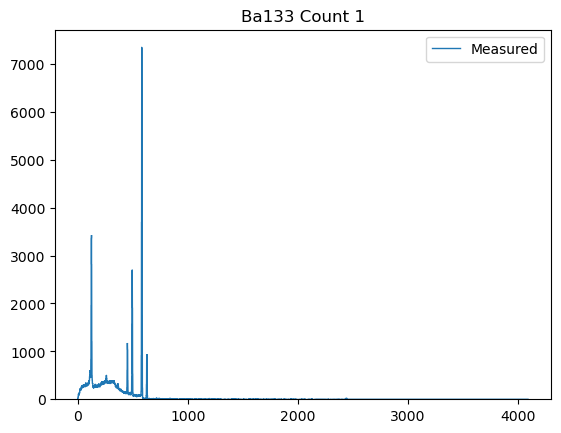

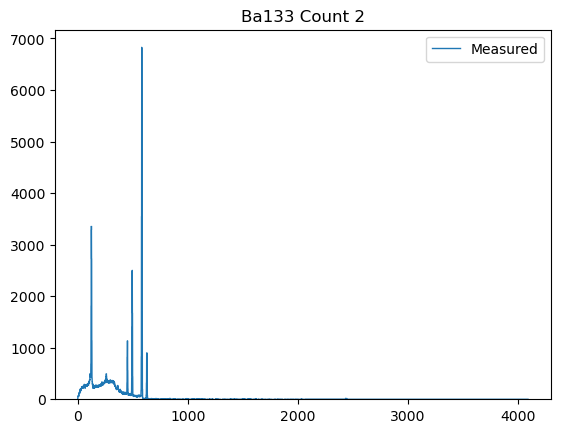

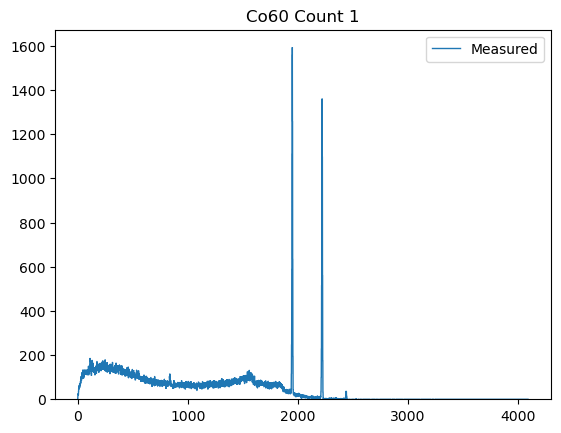

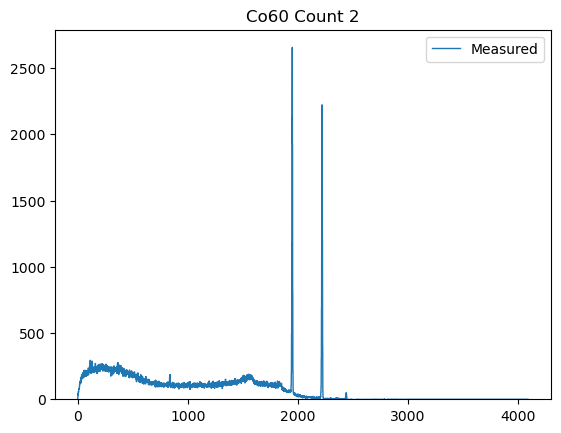

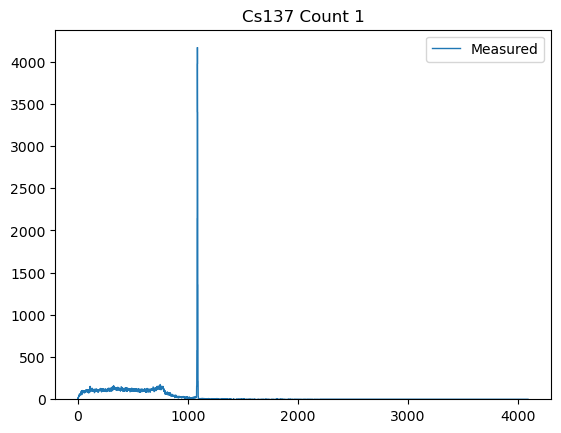

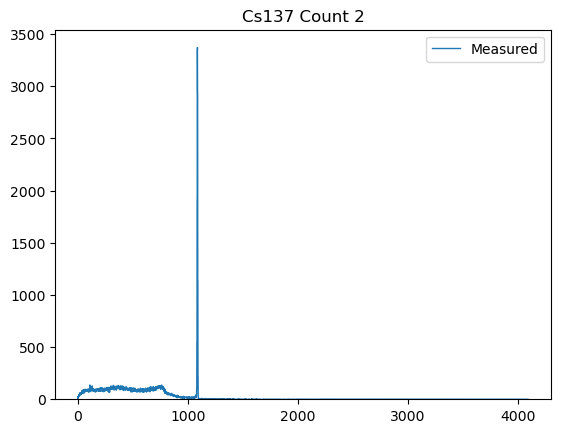

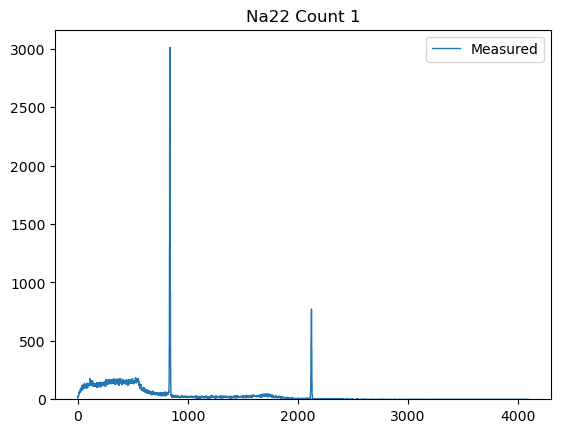

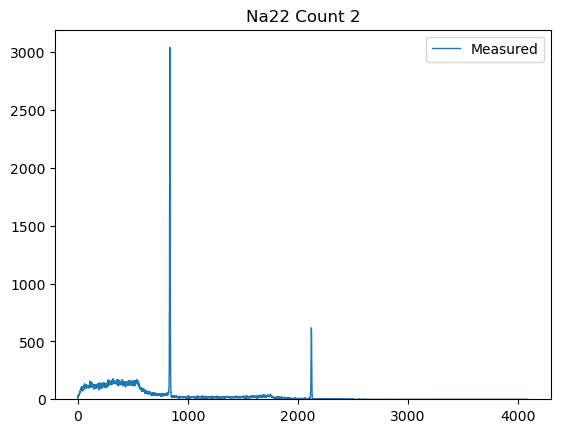

In [4]:
for name, measurement in check_source_measurements.items():
    fig, ax = plt.subplots()
    det = measurement.get_detector(0)
    hist, xvals = det.get_energy_hist()
    ax.stairs(hist, xvals, label=f'Measured')
    ax.legend()
    ax.set_title(name)
    

## Energy Calibration

Using gamma check sources like Co-60 and Cs-137, the characteristic photon peaks from these sources are used to convert the digitizer channel bins into energy (keV) bins

{'Ba133 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18978c800>, 'Ba133 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x1803aae40>, 'Co60 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x188fc96a0>, 'Co60 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x1894604d0>, 'Cs137 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18943a1e0>, 'Cs137 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x1859af560>, 'Na22 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x1897bb740>, 'Na22 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x1897cf7d0>}
Using custom peak finding p

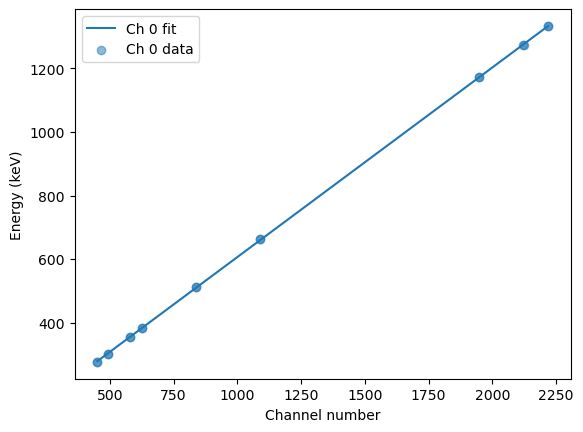

In [5]:
calibration_coeffs = {}
print(check_source_measurements)
channel_nb = check_source_measurements["Ba133 Count 1"].detectors[0].channel_nb

na22_hist, bins = check_source_measurements["Na22 Count 1"].detectors[0].get_energy_hist()

peak_kwargs = {'Na22': {'start_index': 0,
                        'prominence': na22_hist[100:].max() * 0.1,
                        'width': [1, 50],
                        'height': na22_hist[100:].max() * 0.1}}

calibration_channels, calibration_energies = compass.get_calibration_data(
    check_source_measurements.values(),
    background_measurement=background_meas,
    channel_nb=channel_nb,
    peak_kwargs=peak_kwargs,
)

coeff = np.polyfit(calibration_channels, calibration_energies, 1)
calibration_coeffs[channel_nb] = coeff

xs = np.linspace(
    calibration_channels[0],
    calibration_channels[-1],
)
plt.plot(
    xs,
    np.polyval(coeff, xs),
    label=f"Ch {channel_nb} fit",
)
plt.scatter(
    calibration_channels,
    calibration_energies,
    label=f"Ch {channel_nb} data",
    alpha=0.5,
)
plt.xlabel("Channel number")
plt.ylabel("Energy (keV)")
plt.legend()
plt.show()

## Detector Efficiency

Using these same check-sources, each with a known activity, an efficiency curve for each detector is calculated. 

Two types of efficiency curves are shown: 
1. Exponent of sum of logarithms (used in https://doi.org/10.2172/1524045): $ y = \exp(\sum_{i=0}^n a_n \log(E)^i) $

2. Polynomial fit (3rd order): $ y = \sum_{i=0}^n a_n E^i $

**Only the polynomal fit is currently implemented in libra-toolbox, so that is the curve that will be used to calculate the efficiency of the detectors at measuring the activity of the activation foil peaks.**

In [6]:
for name, measurement in check_source_measurements.items():
    for detector in measurement.detectors:
        dead_time_fraction = 1 - detector.live_count_time / detector.real_count_time
        print(f"{name} Ch {detector.channel_nb} \n\t Live time: {detector.live_count_time} s \n\t Real time: {detector.real_count_time} s")
        print(f"\t Dead time fraction: {dead_time_fraction:.2%}")

Ba133 Count 1 Ch 0 
	 Live time: 899.133 s 
	 Real time: 899.502 s
	 Dead time fraction: 0.04%
Ba133 Count 2 Ch 0 
	 Live time: 779.553 s 
	 Real time: 779.96 s
	 Dead time fraction: 0.05%
Co60 Count 1 Ch 0 
	 Live time: 1278.394 s 
	 Real time: 1278.886 s
	 Dead time fraction: 0.04%
Co60 Count 2 Ch 0 
	 Live time: 1998.966 s 
	 Real time: 2000.094 s
	 Dead time fraction: 0.06%
Cs137 Count 1 Ch 0 
	 Live time: 37.206 s 
	 Real time: 37.515 s
	 Dead time fraction: 0.82%
Cs137 Count 2 Ch 0 
	 Live time: 30.093 s 
	 Real time: 30.359 s
	 Dead time fraction: 0.88%
Na22 Count 1 Ch 0 
	 Live time: 24.559 s 
	 Real time: 24.959 s
	 Dead time fraction: 1.60%
Na22 Count 2 Ch 0 
	 Live time: 18.987 s 
	 Real time: 19.322 s
	 Dead time fraction: 1.73%


In [7]:
def eff_curve_func(E, *a):
    exponent_term = 0
    for i,a_n in enumerate(a):
        exponent_term += a_n * (np.log(E) ** i)
    return np.exp(exponent_term)

/var/folders/8l/th_q6c756gb0yy2fvkvdjntr0000gn/T/ipykernel_64169/695408961.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


[278.69444115 304.35112006 356.26114484 383.7078246 ]
[np.float64(278.69444114949727)]
Fitted parameters: [ 4.14308652e+02 -1.02753095e+00  1.08658923e+03  2.78770580e+02
 -1.21152326e+00]
[np.float64(304.3511200612196)]
Fitted parameters: [ 4.91362540e+02 -1.29143390e+00  2.58669564e+03  3.04755715e+02
 -1.23257567e+00]
[np.float64(356.26114483609973)]
Fitted parameters: [ 8.30487152e+02 -2.19109652e+00  7.45524981e+03  3.56851334e+02
 -1.24020048e+00]
[np.float64(383.7078246021283)]
Fitted parameters: [ 1.26913626e+02 -2.91724627e-01  9.62343698e+02  3.84139875e+02
 -1.25152560e+00]

[278.69444115 304.35112006 356.26114484 383.7078246 ]
[np.float64(278.69444114949727)]
Fitted parameters: [ 3.53703702e+02 -9.04544961e-01  1.04324764e+03  2.78779419e+02
 -1.18417164e+00]
[np.float64(304.3511200612196)]
Fitted parameters: [ 3.62878223e+02 -9.33902434e-01  2.43426888e+03  3.04734537e+02
 -1.19515001e+00]
[np.float64(356.26114483609973)]
Fitted parameters: [ 6.91332842e+02 -1.83023105e+00

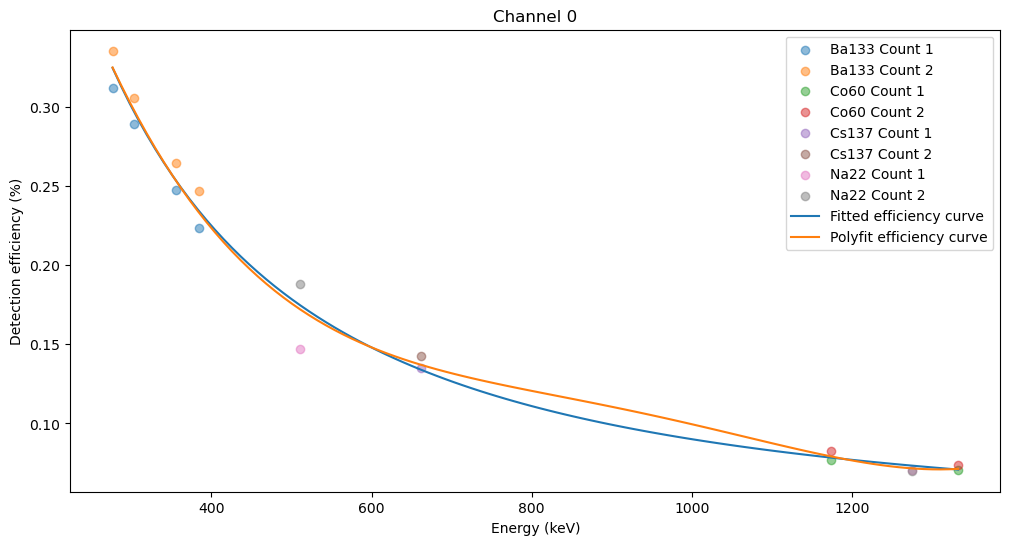

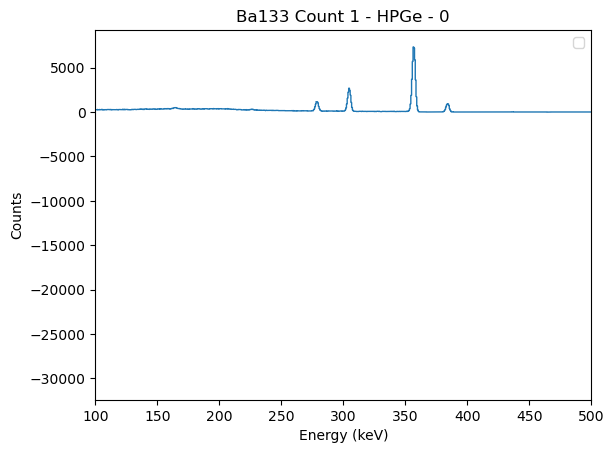

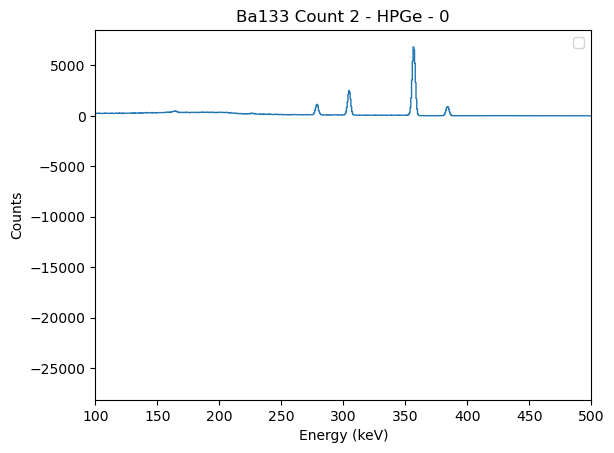

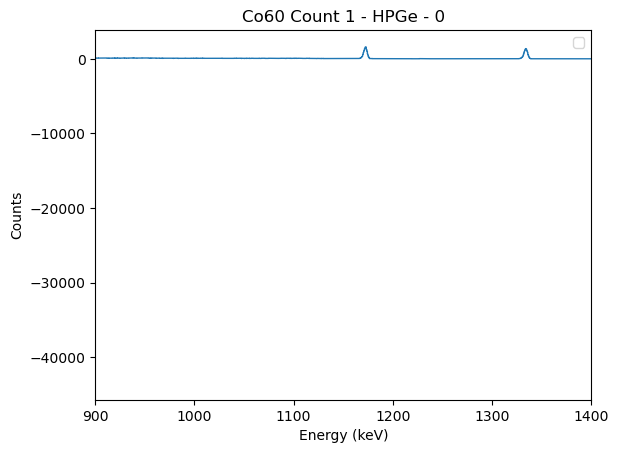

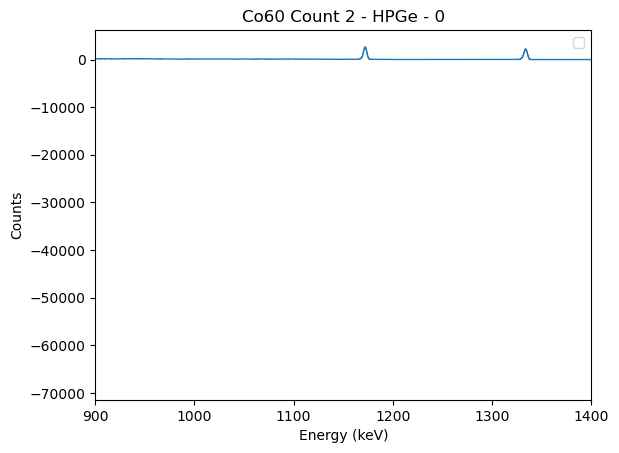

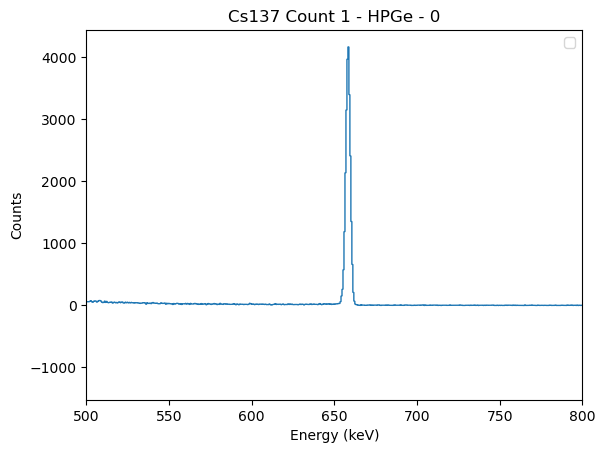

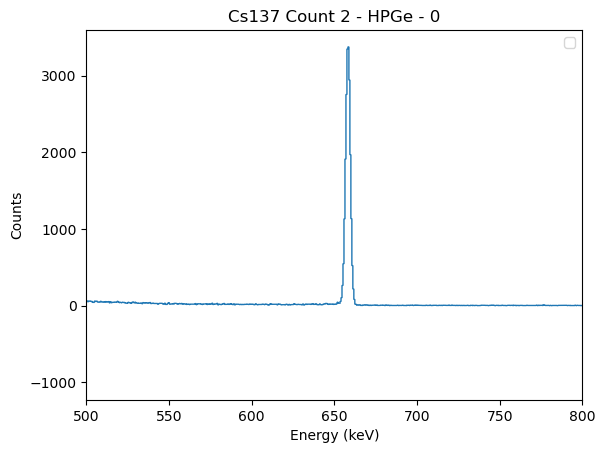

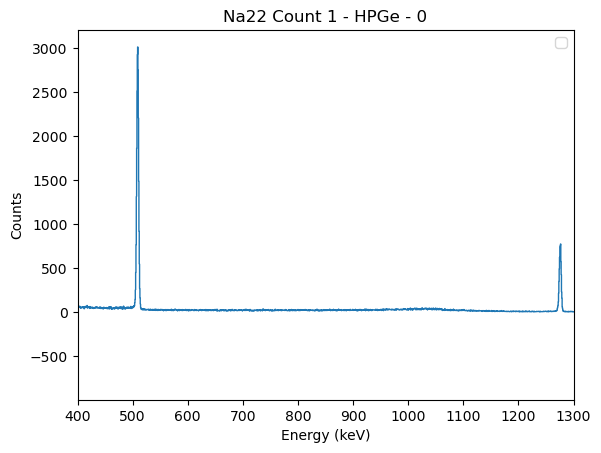

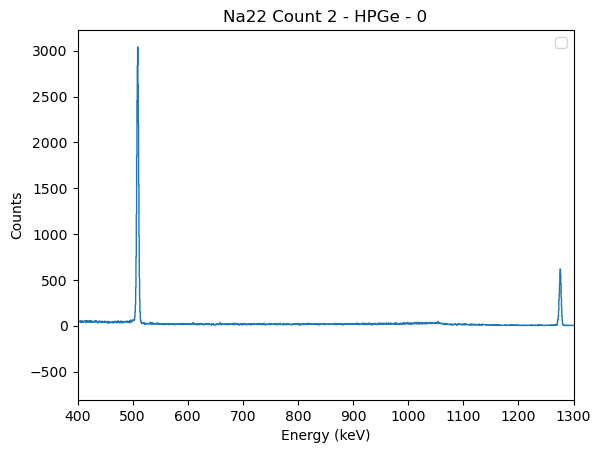

In [8]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

channels = []
efficiency_coeffs = {}
measurement = list(check_source_measurements.values())[0]

# search_widths = np.arange(20, 50, 2)
# for search_width in search_widths:
search_width = 20
threshold_overlap = 10
for detector in measurement.detectors:
    channels.append(detector.channel_nb)

xlim_dict = {
    'Ba133': [100, 500],
    'Co60': [900, 1400],
    'Cs137': [500, 800],
    'Mn54': [600, 900],
    'Na22': [400, 1300],
}

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))

background_detector = background_meas.get_detector(channel_nb)
energies = []
efficiencies = []
for name, measurement in check_source_measurements.items():
    check_source_detector = measurement.get_detector(channel_nb)
    hist, bin_edges = check_source_detector.get_energy_hist_background_substract(background_detector, bins=None)
    calibrated_bin_edges = np.polyval(calibration_coeffs[channel_nb], bin_edges)

    # plot the histogram
    fig2,ax2 = plt.subplots()
    ax2.stairs(hist, calibrated_bin_edges)
    # ax2.set_xlim(left=0, right=500)

    # See how well calibrated peaks match expected energies
    expected_energies = measurement.check_source.nuclide.energy
    for energy in expected_energies:
        lower_ind = np.argmin(np.abs((energy - search_width) - calibrated_bin_edges))
        upper_ind = np.argmin(np.abs((energy + search_width) - calibrated_bin_edges))
        hist_search = hist[lower_ind:upper_ind]

        peaks, peak_params = find_peaks(hist_search, height=np.max(hist_search) * 0.5)

    # print('notebook search_width:', search_width, ' threshold_overlap:', threshold_overlap)

    # uncalibrated = np.array(
    #             measurement.check_source.nuclide._uncalibrated_measured_energies.get(channel_nb, []),
    #             dtype=float
    #         )
    # calibrated_ergs = np.polyval(calibration_coeffs[channel_nb], uncalibrated)


    ax2.set_xlabel("Energy (keV)")
    ax2.set_ylabel("Counts")
    ax2.set_title(f"{measurement.name} - {measurement.detector_type} - {channel_nb}")
    ax2.legend()
    nuclide = name.split()[0]
    if nuclide in xlim_dict:
        ax2.set_xlim(left=xlim_dict[nuclide][0], right=xlim_dict[nuclide][1])
    else:
        ax2.set_xlim(left=0, right=1500)
    
    efficiency = measurement.compute_detection_efficiency(
        background_measurement=background_meas,
        calibration_coeffs=calibration_coeffs[channel_nb],
        channel_nb=channel_nb,
        search_width=search_width,
        threshold_overlap=threshold_overlap,
        # summing_method='sum_gaussian',
        summing_method='sum_histogram'
    )
    print("\n" + "=" * 40)

    energies += measurement.check_source.nuclide.energy
    efficiencies += list(efficiency)
    ax.scatter(
        measurement.check_source.nuclide.energy,
        efficiency * 100,
        label=name,
        alpha=0.5
    )

# Sort energies and efficiencies for fitting
sorted_indices = np.argsort(energies)
energies = np.array(energies)[sorted_indices]
efficiencies = np.array(efficiencies)[sorted_indices]
print(f"Ch {channel_nb} \n\t Energies: {energies}, \n\t Efficiencies: {efficiencies}")

# Fit the efficiency curve
popt, pcov = curve_fit(
    eff_curve_func,
    energies,
    efficiencies,
    p0=[-1, 1, 0, 0],
)

poly_coeff = np.polyfit(energies, efficiencies, 4)
efficiency_coeffs[channel_nb] = poly_coeff
xs = np.linspace(
    energies[0],
    energies[-1],
    100,
)
ax.plot(
    xs,
    eff_curve_func(xs, *popt) * 100,
    label="Fitted efficiency curve",
)

ax.plot(
    xs,
    np.polyval(poly_coeff, xs) * 100,
    label="Polyfit efficiency curve",
)
ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Detection efficiency (%)")
ax.set_title(f"Channel {channel_nb}")
ax.legend()
# plt.ylim(bottom=0)
print(popt)
plt.show()

## Calculating average neutron rate from activation foils

First, the irradiation schedule and the foil information is collected.

In [9]:
all_neutron_rates = []
all_neutron_rates_err = []

## Irradiation Time

Index(['Elapsed (s)', 'Time', 'nGen-400 Uptime', 'nGen-400 Hours',
       'Anode PWM_Duty_Cycle', 'Anode Voltage', 'Anode Current',
       'Getter PWM_Duty_Cycle', 'Getter Current', 'Neutron Counts',
       'Neutron Count_Rate', 'Neutron Count_Rate_Avg',
       'Neutron Count_Rate_Stdev_Pct', 'RF Freq_Synth', 'Suppressor Current',
       'Suppressor Voltage', 'Pulsing Rep_Rate', 'Pulsing Duty_Cycle',
       'Pulsing Ext_Trig_Select', 'Calculations Current_Ratio',
       'Faults Anode_Voltage_Too_High', 'Faults Arc_dI_dt', 'Faults Arc_I',
       'Faults Blinkout', 'Faults E_Beam_Power_Too_High', 'Faults Interlock',
       'Faults Suppressor_Voltage_Too_Low', 'State_Machine State',
       'State_Machine Source', 'State_Machine Destination',
       'State_Machine Fault'],
      dtype='object')


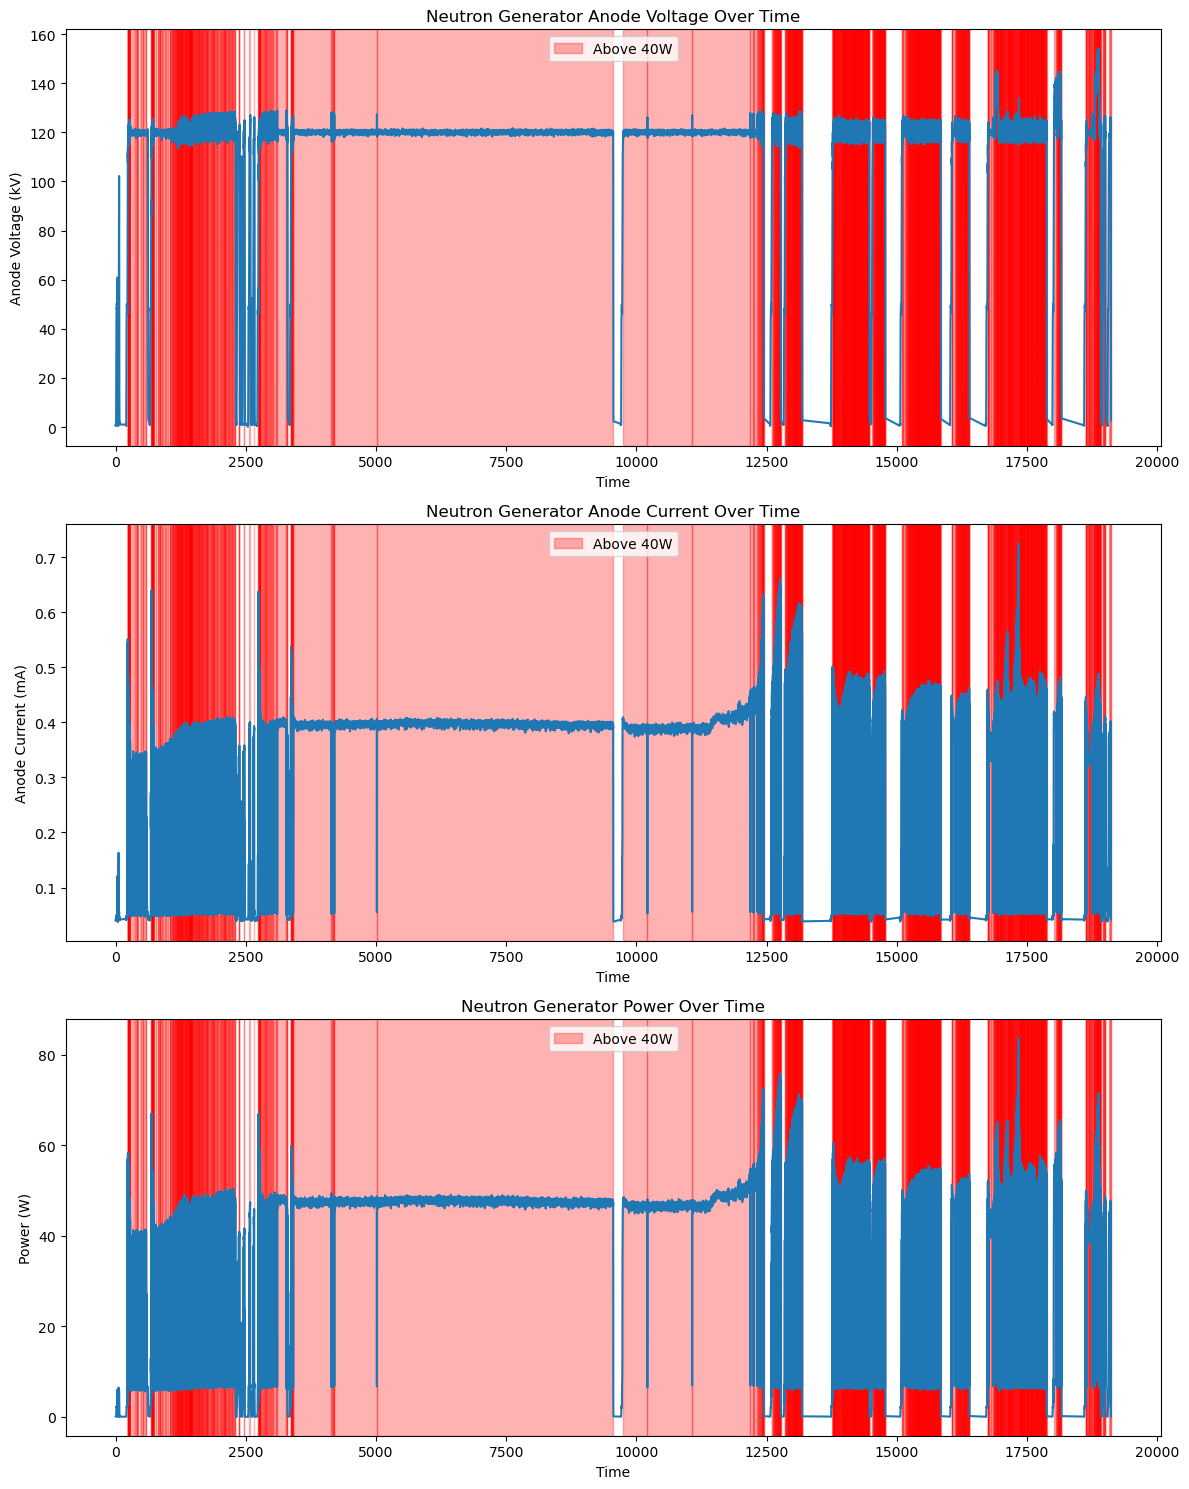

In [ ]:
import pandas as pd
ngen_log_csv_path = '../../data/neutron_generator/nGen-400 2026-03-10 10.27.10.csv'
df = pd.read_csv(ngen_log_csv_path)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15))
print(df.columns)
axes[0].plot(df['Elapsed (s)'], df['Anode Voltage'])
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Anode Voltage (kV)")
axes[0].set_title("Neutron Generator Anode Voltage Over Time")

axes[1].plot(df['Elapsed (s)'], df['Anode Current'])
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Anode Current (mA)")
axes[1].set_title("Neutron Generator Anode Current Over Time")

axes[2].plot(df['Elapsed (s)'], df['Anode Voltage'] * df['Anode Current'])  # Convert mA to A for power calculation
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Power (W)")
axes[2].set_title("Neutron Generator Power Over Time")

above_40W_mask = (df['Anode Voltage'] * df['Anode Current']) > 40 

# Find transitions in the mask to identify region boundaries
mask_array = above_40W_mask.values.astype(int)
mask_diff = np.diff(np.concatenate([[0], mask_array, [0]]))
region_starts = np.where(mask_diff == 1)[0]  # Rising edges (start of region)
region_ends = np.where(mask_diff == -1)[0]    # Falling edges (end of region)

# Filter out regions shorter than a minimum duration (e.g., 5 seconds)
min_duration = 5  # seconds
valid_regions = []
for start_idx, end_idx in zip(region_starts, region_ends):
    duration = df['Elapsed (s)'].iloc[end_idx - 1] - df['Elapsed (s)'].iloc[start_idx]
    if duration >= min_duration:
        valid_regions.append((start_idx, end_idx))

# Shade each valid region on all axes
for ax in axes:
    for i, (start_idx, end_idx) in enumerate(valid_regions):
        label = 'Above 40W' if i == 0 else None
        ax.axvspan(df['Elapsed (s)'].iloc[start_idx], df['Elapsed (s)'].iloc[end_idx], 
                   color='red', alpha=0.3, label=label)
    ax.legend()
plt.tight_layout()


In [10]:
from process_foil_data import irradiations, time_generator_off

## Background Measurements

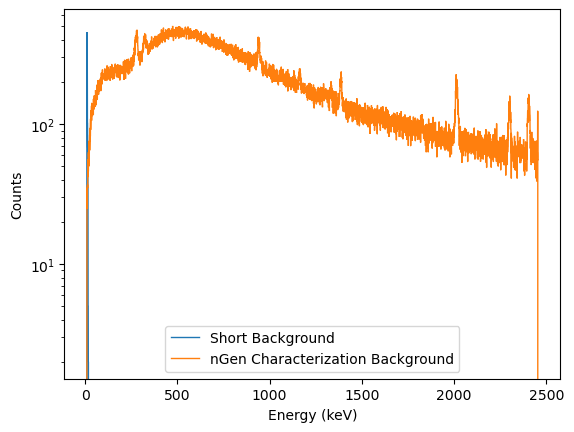

In [11]:
from libra_toolbox.neutron_detection.activation_foils.compass import Measurement

background_detector1 = background_meas.get_detector(channel_nb)
background_meas2 = Measurement.from_directory(
        '../../data/neutron_detection/activation_foils/260310_1L_FLiBe_run2/DAQ/Background_long_count1_feb2026_nGen_charac/UNFILTERED',
        name="Background_nGen_charac",
        info_file_optional=False,
    )
background_detector2 = background_meas2.get_detector(channel_nb)

fig, ax = plt.subplots()
hist1, bin_edges1 = background_detector1.get_energy_hist()
calibrated_bin_edges1 = np.polyval(calibration_coeffs[channel_nb], bin_edges1)
ax.stairs(hist1, calibrated_bin_edges1, label="Short Background")
hist2, bin_edges2 = background_detector2.get_energy_hist()
calibrated_bin_edges2 = np.polyval(calibration_coeffs[channel_nb], bin_edges2)
ax.stairs(hist2, calibrated_bin_edges2, label="nGen Characterization Background")
ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")
ax.legend()
ax.set_yscale("log")

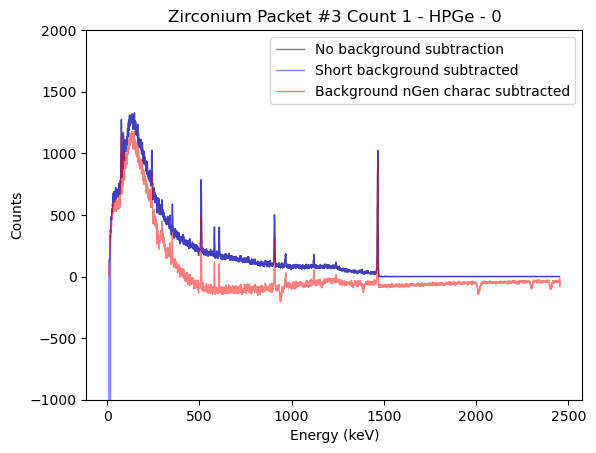

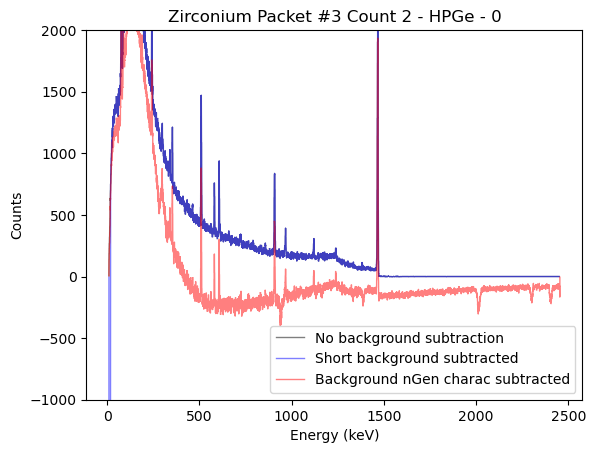

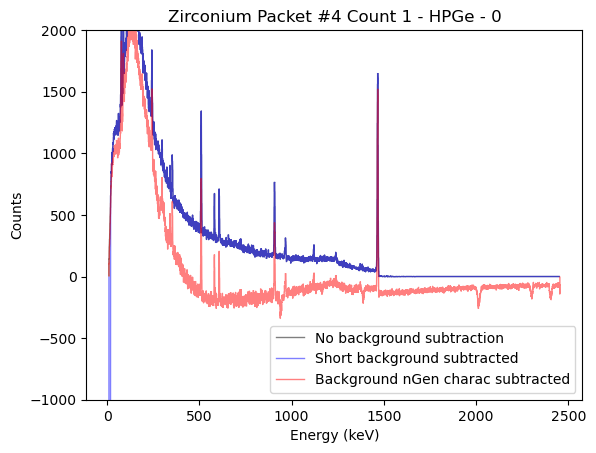

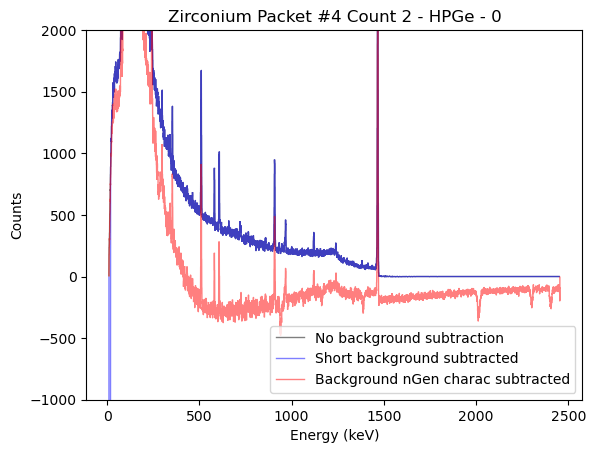

In [12]:
for name, foil_measurement in foil_measurements.items():
    for count_num, measurement in foil_measurement['measurements'].items():
        detector = measurement.get_detector(channel_nb)

        hist_no_sub, bin_edges_no_sub = detector.get_energy_hist(bins=None)
        calibrated_bin_edges_no_sub = np.polyval(calibration_coeffs[channel_nb], bin_edges_no_sub)
        hist1, bin_edges1 = detector.get_energy_hist_background_substract(background_detector1, bins=None)
        calibrated_bin_edges1 = np.polyval(calibration_coeffs[channel_nb], bin_edges)

        hist2, bin_edges2 = detector.get_energy_hist_background_substract(background_detector2, bins=None)
        calibrated_bin_edges2 = np.polyval(calibration_coeffs[channel_nb], bin_edges)

        fig, ax = plt.subplots()
        ax.stairs(hist_no_sub, calibrated_bin_edges_no_sub, color='black', alpha=0.5, label='No background subtraction')
        ax.stairs(hist1, calibrated_bin_edges1, color='blue', alpha=0.5, label='Short background subtracted')
        ax.stairs(hist2, calibrated_bin_edges2, color='red', alpha=0.5, label='Background nGen charac subtracted')
        ax.set_xlabel("Energy (keV)")
        ax.set_ylabel("Counts")
        ax.set_title(f"{measurement.name} - {measurement.detector_type} - {channel_nb}")
        # ax.set_yscale('log')
        ax.legend()
        ax.set_ylim(bottom=-1e3, top=2e3)

## Which Background to Use

The HPGe broke during the background count, which only lasted a few minutes and was dominated by the low energy counts, so may have even been broken at the start. So doing background subtraction with this background produces the same spectrum at relevant energies for the check sources and activation foil gammas.

Since a similar setup was used for the nGen characterization, we tried to use the background count from that experiment, but as can be seen above, the background subtraction yields a spectrum with peak bases that have negative counts. When computing neutron rates from the foils using this background subtraction, the peak fitting doesn't work well, so some measurements show 0 neutrons while others don't yield any result. 

Therefore, the short background with only low energy counts will be used, which is effectively the same as no background subtraction at all for the relevant energy ranges.

### Zirconium Packet #3 Results

The activity of Zr-89 is measured using its 909 keV gamma peak and used to determine the neutron rate during the irradiation. Zr-89 is formed from the Zr-90(n,2n) reaction, which has a threshold energy of ~12 MeV. 

The gamma spectrum obtained from the various measurements of the Zirconium Packet #3 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [13]:
print(foil_measurements["Zirconium Packet #3"])

{'measurement_paths': {1: PosixPath('../../data/neutron_detection/activation_foils/260310_1L_FLiBe_run2/DAQ/Zr_foil3_10Mar2026/UNFILTERED'), 2: PosixPath('../../data/neutron_detection/activation_foils/260310_1L_FLiBe_run2/DAQ/Zr_foil3_10Mar2026_count2/UNFILTERED')}, 'foil': ActivationFoil(reaction=Reaction(reactant=Nuclide(name='Zr90', energy=None, intensity=None, half_life=None, atomic_mass=89.90469876, abundance=0.515), product=Nuclide(name='Zr89', energy=[909.15], intensity=[0.9904], half_life=282276.0, atomic_mass=None, abundance=1.0), cross_section=6.2389e-25), mass=0.4498, name='Zirconium Packet #3', density=6.505, thickness=0.050800000000000005), 'distance_to_source': 5, 'measurements': {1: <libra_toolbox.neutron_detection.activation_foils.compass.SampleMeasurement object at 0x184ac7ad0>, 2: <libra_toolbox.neutron_detection.activation_foils.compass.SampleMeasurement object at 0x1897cd250>}}


In [14]:
from process_foil_data import calculate_neutron_rate_from_foil

foil_name = "Zirconium Packet #3"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=15)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])


[909.15]
Fitted parameters: [ 4.78699372e+02 -4.25643933e-01  4.04265052e+02  9.07323351e+02
  1.90878022e+00]
[909.15]
Fitted parameters: [ 7.34511880e+02 -5.96185975e-01  6.71949999e+02  9.07427570e+02
  1.91163379e+00]
Count 1
	 Ch 0: Neutron rate: 8.758e+08 +/- 1.995e+07 n/s
Count 2
	 Ch 0: Neutron rate: 9.554e+08 +/- 1.688e+07 n/s


### Zirconium Packet #4 Results

The activity of Zr-89 is measured using its 909 keV gamma peak and used to determine the neutron rate during the irradiation. Zr-89 is formed from the Zr-90(n,2n) reaction, which has a threshold energy of 12.1 MeV. 

The gamma spectrum obtained from the various measurements of the Zirconium Packet #1 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [15]:
foil_name = "Zirconium Packet #4"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=15)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])

[909.15]
Fitted parameters: [ 6.25638724e+02 -5.00596129e-01  5.94404815e+02  9.07238287e+02
  1.98248781e+00]
[909.15]
Fitted parameters: [ 9.82016426e+02 -8.33583296e-01  6.94336541e+02  9.07579407e+02
  1.92329798e+00]
Count 1
	 Ch 0: Neutron rate: 8.544e+08 +/- 1.576e+07 n/s
Count 2
	 Ch 0: Neutron rate: 1.019e+09 +/- 1.767e+07 n/s


### Averaging foil results

The average of the neutron rates of the Niobium and Zirconium foil packets is calculated and added to the processed_data.json file. 

In [16]:
average_neutron_rate = np.mean(all_neutron_rates)
# average_neutron_rate_err = np.sqrt(np.sum(np.array(all_neutron_rates_err) ** 2)) / len(all_neutron_rates_err)
average_neutron_rate_err = np.std(all_neutron_rates, ddof=1)  # Use ddof=1 for sample standard deviation

print(f"Average neutron rate: {average_neutron_rate:.3e} ± {average_neutron_rate_err:.3e} n/s")

Average neutron rate: 9.262e+08 ± 7.569e+07 n/s


In [17]:
processed_data_file = "../../data/processed_data.json"

processed_data = {
    "neutron_rate_used_in_model": {
        "value":average_neutron_rate,
        "error": average_neutron_rate_err,
        "unit": "neutron / second"
    }
}

try:
    with open(processed_data_file, "r") as f:
        existing_data = json.load(f)
except FileNotFoundError:
    print(f"Processed data file not found, creating it in {processed_data_file}")
    existing_data = {}

existing_data.update(processed_data)

with open(processed_data_file, "w") as f:
    json.dump(existing_data, f, indent=4)

print(f"Processed data stored in {processed_data_file}")

Processed data stored in ../../data/processed_data.json
